# Spatial Cluster View

Plot all input halos in a spatial region, colored by cluster ID.

In [11]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [24]:
# === CONFIGURATION ===

# HDF5 file to plot
filepath = "../output/dbscan_clusters_eps_4.0_ms_12.h5"

# Spatial region to plot (centered on observer at box center)
center = [536.7, 543.1, 550.3]  # Mpc (Persus cluster position)
window_size = 30  # Mpc (half-width)

# Depth slice along the third axis (None = all depths)
depth_slice = 30  # Mpc (None to include all)

# All three projections will be shown
projections = ['xy', 'xz', 'yz']

In [25]:
def load_halo_data(filepath):
    """Load positions and cluster labels from HDF5 file."""
    with h5py.File(filepath, 'r') as f:
        # Try input_catalog first (new format), fall back to assignments
        if 'input_catalog' in f:
            grp = f['input_catalog']
            positions = grp['positions'][:]
            labels = grp['cluster_ids'][:]
        elif 'assignments' in f:
            grp = f['assignments']
            x, y, z = grp['x'][:], grp['y'][:], grp['z'][:]
            positions = np.column_stack([x, y, z])
            labels = grp['label'][:]
        else:
            raise ValueError(f"No halo data found in {filepath}")
    return positions, labels


def filter_region(positions, labels, center, window_size, projection, depth_slice):
    """Filter halos within the specified spatial region."""
    axis_map = {'xy': (0, 1, 2), 'xz': (0, 2, 1), 'yz': (1, 2, 0)}
    ax1, ax2, ax3 = axis_map[projection]
    
    # Filter by 2D window
    mask = (
        (np.abs(positions[:, ax1] - center[ax1]) <= window_size) &
        (np.abs(positions[:, ax2] - center[ax2]) <= window_size)
    )
    
    # Optional depth slice
    if depth_slice is not None:
        mask &= np.abs(positions[:, ax3] - center[ax3]) <= depth_slice
    
    return positions[mask], labels[mask], (ax1, ax2)

/tmp/ipykernel_17504/1097135602.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tab20 = plt.cm.get_cmap('tab20').colors  # 20 RGBA tuples


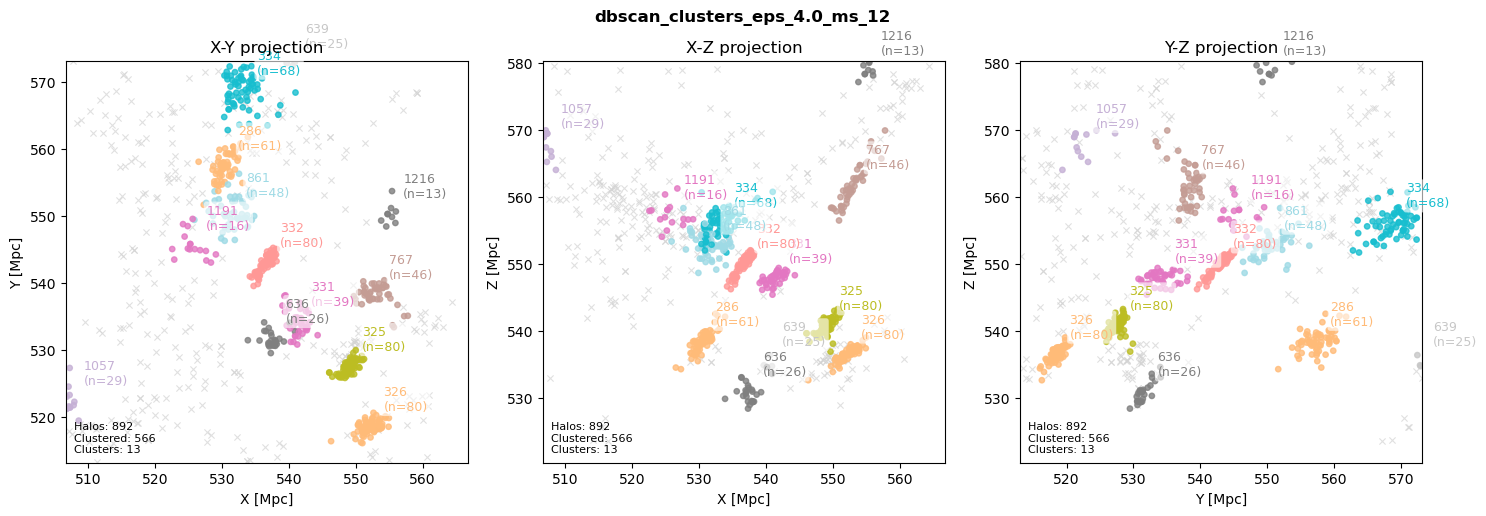

In [26]:
# Create figure with three panels (one per projection)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
offset = 2

axis_labels = {0: 'X', 1: 'Y', 2: 'Z'}
projection_titles = {'xy': 'X-Y projection', 'xz': 'X-Z projection', 'yz': 'Y-Z projection'}

# Load data once
positions, labels = load_halo_data(filepath)

# Compute cluster sizes in the FULL dataset (not filtered region)
full_cluster_sizes = {
    cid: int(np.sum(labels == cid))
    for cid in np.unique(labels)
    if cid != -1
}

# Random (but repeatable) color assignment from tab20
rng = np.random.default_rng(0)
tab20 = plt.cm.get_cmap('tab20').colors  # 20 RGBA tuples

# Get all unique cluster IDs (excluding noise) for consistent coloring across panels
all_cluster_ids = sorted([cid for cid in np.unique(labels) if cid != -1])
perm = rng.permutation(len(tab20))
global_color_map = {cid: tab20[perm[j % len(tab20)]] for j, cid in enumerate(all_cluster_ids)}

for ax, projection in zip(axes, projections):
    pos_filt, lab_filt, (ax1, ax2) = filter_region(
        positions, labels, center, window_size, projection, depth_slice
    )

    # Separate noise (-1) from clustered halos (in filtered view)
    noise_mask = lab_filt == -1

    # Plot noise halos as crosses
    ax.scatter(
        pos_filt[noise_mask, ax1], pos_filt[noise_mask, ax2],
        c='lightgray', s=20, alpha=0.7, marker='x', linewidths=0.8
    )

    # Plot clustered halos with consistent colors across all panels
    clustered = ~noise_mask
    if np.any(clustered):
        cluster_ids = np.unique(lab_filt[clustered])
        point_colors = np.array([global_color_map[cid] for cid in lab_filt[clustered]])

        ax.scatter(
            pos_filt[clustered, ax1], pos_filt[clustered, ax2],
            c=point_colors, s=15, alpha=0.8
        )

        # Annotate each cluster with offset
        for cid in cluster_ids:
            mask_c = lab_filt == cid
            x0 = float(np.mean(pos_filt[mask_c, ax1]))
            y0 = float(np.mean(pos_filt[mask_c, ax2]))

            n_members = full_cluster_sizes.get(cid, int(np.sum(labels == cid)))

            ax.text(
                x0 + offset,
                y0 + offset,
                f'{cid}\n(n={n_members})',
                color=global_color_map[cid],
                fontsize=9,
                ha='left', va='bottom',
                bbox=dict(
                    boxstyle='round,pad=0.2',
                    facecolor='white',
                    edgecolor='none',
                    alpha=0.6
                )
            )

    # Set equal axis limits to make square panels
    ax.set_xlim(center[ax1] - window_size, center[ax1] + window_size)
    ax.set_ylim(center[ax2] - window_size, center[ax2] + window_size)
    ax.set_aspect('equal', adjustable='box')
    
    ax.set_xlabel(f'{axis_labels[ax1]} [Mpc]')
    ax.set_ylabel(f'{axis_labels[ax2]} [Mpc]')
    ax.set_title(projection_titles[projection])

    n_total = len(lab_filt)
    n_clustered = int(np.sum(clustered))
    n_clusters = int(len(np.unique(lab_filt[clustered]))) if np.any(clustered) else 0
    ax.text(
        0.02, 0.02,
        f'Halos: {n_total}\nClustered: {n_clustered}\nClusters: {n_clusters}',
        transform=ax.transAxes, fontsize=8, va='bottom'
    )

fig.suptitle(Path(filepath).stem, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()